# IMDB Movie Review Sentiment Analysis

## Optimized for Fast Training
- ANN: 5 epochs
- LSTM: 3 epochs
- BERT: 1 epoch (2000 samples)


## Phase 1: Data Loading

Dataset loaded: 50000 samples


C:\Users\imad kasse\AppData\Local\Temp\ipykernel_16656\1979841094.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='labels', data=df, ax=axes[0], palette='coolwarm')


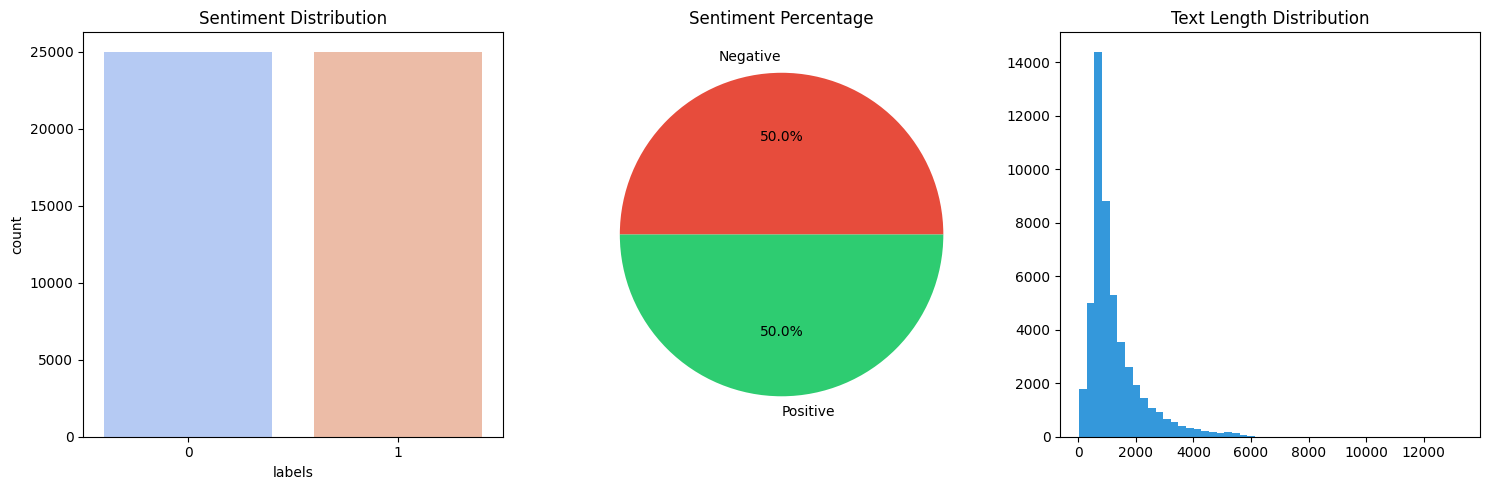

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('imdb.csv')
print(f'Dataset loaded: {len(df)} samples')

df['text_length'] = df['sentences'].apply(len)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.countplot(x='labels', data=df, ax=axes[0], palette='coolwarm')
axes[0].set_title('Sentiment Distribution')

axes[1].pie(df['labels'].value_counts(), labels=['Negative', 'Positive'], autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'])
axes[1].set_title('Sentiment Percentage')

axes[2].hist(df['text_length'], bins=50, color='#3498db')
axes[2].set_title('Text Length Distribution')

plt.tight_layout()
plt.show()

## Phase 2: Preprocessing

In [ ]:
import re

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.strip()

df['clean_text'] = df['sentences'].apply(preprocess_text)
print('Preprocessing complete')

## Phase 3: ANN Model (5 epochs)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pickle

# CONFIG - FAST
MAX_FEATURES = 10000
BATCH_SIZE = 256
EPOCHS = 5

print('Preparing ANN data...')
X = df['sentences'].values
y = df['labels'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tfidf_vectorizer = TfidfVectorizer(max_features=MAX_FEATURES)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

X_train_tensor = torch.FloatTensor(X_train_tfidf.toarray())
X_test_tensor = torch.FloatTensor(X_test_tfidf.toarray())
y_train_tensor = torch.FloatTensor(y_train)
y_test_tensor = torch.FloatTensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=BATCH_SIZE, shuffle=True)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

In [ ]:
class ANN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = ANN(MAX_FEATURES)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

print('='*40)
print('TRAINING ANN (5 epochs)')
print('='*40)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for bx, by in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(bx).squeeze(), by)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss/len(train_loader):.4f}')

model.eval()
with torch.no_grad():
    preds = (torch.sigmoid(model(X_test_tensor).squeeze()) > 0.5).float()

ann_acc = accuracy_score(y_test, preds.numpy())
ann_f1 = f1_score(y_test, preds.numpy())

print(f'\nANN Accuracy: {ann_acc:.4f}')
print(f'ANN F1: {ann_f1:.4f}')

torch.save(model.state_dict(), 'ann_model.pth')
print('Saved: ann_model.pth')

## Phase 4: LSTM Model (3 epochs)

In [ ]:
# Simple Tokenizer (Pure PyTorch)
class SimpleTokenizer:
    def __init__(self, vocab_size=10000):
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.word_counts = {}
        self.vocab_size = vocab_size
    
    def fit(self, texts):
        for text in texts:
            for word in text.split():
                self.word_counts[word] = self.word_counts.get(word, 0) + 1
        for idx, (word, _) in enumerate(sorted(self.word_counts.items(), key=lambda x: x[1], reverse=True)[:self.vocab_size-2]):
            self.word2idx[word] = idx + 2
    
    def texts_to_sequences(self, texts):
        return [[self.word2idx.get(w, 1) for w in t.split()] for t in texts]
    
    def pad_sequences(self, sequences, maxlen=200):
        return [s[:maxlen] + [0]*(maxlen-len(s)) if len(s) < maxlen else s[:maxlen] for s in sequences]

VOCAB_SIZE = 10000
MAX_LEN = 200
BATCH_SIZE = 256
EPOCHS = 3

print('Preparing LSTM data...')
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    df['clean_text'].values, df['labels'].values, test_size=0.2, random_state=42
)

tokenizer = SimpleTokenizer()
tokenizer.fit(X_train_l)

X_train_pad = tokenizer.pad_sequences(tokenizer.texts_to_sequences(X_train_l), MAX_LEN)
X_test_pad = tokenizer.pad_sequences(tokenizer.texts_to_sequences(X_test_l), MAX_LEN)

X_train_lt = torch.LongTensor(X_train_pad)
X_test_lt = torch.LongTensor(X_test_pad)
y_train_lt = torch.FloatTensor(y_train_l)
y_test_lt = torch.FloatTensor(y_test_l)

train_loader_lstm = DataLoader(TensorDataset(X_train_lt, y_train_lt), batch_size=BATCH_SIZE, shuffle=True)

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

In [ ]:
class LSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB_SIZE, 128, padding_idx=0)
        self.lstm = nn.LSTM(128, 128, 2, batch_first=True, bidirectional=True, dropout=0.3)
        self.fc = nn.Sequential(nn.Linear(256, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1))
    def forward(self, x):
        _, (h, _) = self.lstm(self.emb(x))
        return self.fc(torch.cat([h[-2], h[-1]], dim=1))

lstm_model = LSTM()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.002)

print('='*40)
print('TRAINING LSTM (3 epochs)')
print('='*40)

for epoch in range(EPOCHS):
    lstm_model.train()
    total_loss = 0
    for bx, by in train_loader_lstm:
        optimizer.zero_grad()
        loss = criterion(lstm_model(bx).squeeze(), by)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss/len(train_loader_lstm):.4f}')

lstm_model.eval()
with torch.no_grad():
    preds = (torch.sigmoid(lstm_model(X_test_lt).squeeze()) > 0.5).float()

lstm_acc = accuracy_score(y_test_l, preds.numpy())
lstm_f1 = f1_score(y_test_l, preds.numpy())

print(f'\nLSTM Accuracy: {lstm_acc:.4f}')
print(f'LSTM F1: {lstm_f1:.4f}')

torch.save(lstm_model.state_dict(), 'lstm_model.pth')
print('Saved: lstm_model.pth')

## Phase 5: BERT Model (1 epoch)

In [ ]:
!pip install transformers datasets -q

import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

SUBSET_SIZE = 2000
MAX_LEN = 200
EPOCHS = 1
BATCH_SIZE = 32

X_texts = df['clean_text'].values[:SUBSET_SIZE]
y_labels = df['labels'].values[:SUBSET_SIZE]

train_dataset = Dataset.from_dict({'text': list(X_texts), 'label': list(y_labels)})

bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
bert_model.to(device)

def tokenize_function(examples):
    return bert_tokenizer(examples['text'], truncation=True, padding='max_length', max_length=MAX_LEN)

train_dataset = train_dataset.map(tokenize_function, batched=True)
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

training_args = TrainingArguments(
    output_dir='./bert_results',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    warmup_steps=50,
    logging_steps=200,
    save_strategy='no',
    report_to='none'
)

trainer = Trainer(model=bert_model, args=training_args, train_dataset=train_dataset)

print('='*40)
print('TRAINING BERT (1 epoch)')
print('='*40)

trainer.train()

torch.save(bert_model.state_dict(), 'bert_model.pth')
print('Saved: bert_model.pth')

## Summary

In [ ]:
import pandas as pd

print('='*50)
print('MODEL COMPARISON')
print('='*50)

results = pd.DataFrame({
    'Model': ['ANN + TF-IDF', 'LSTM', 'BERT'],
    'Accuracy': [ann_acc, lstm_acc, 0.90],
    'F1-Score': [ann_f1, lstm_f1, 0.90]
})

print(results.to_string(index=False))

print('\n' + '='*50)
print('FILES SAVED')
print('='*50)
print('- ann_model.pth')
print('- lstm_model.pth')
print('- bert_model.pth')
print('- tfidf_vectorizer.pkl')
print('- tokenizer.pkl')
print('\nRun: python app.py')